# Q1  - Baseline Model for Financial Time Series

In this question, I build a simple baseline model to predict future closing prices using past values.

The goal is to check whether the dataset contains predictable time-series structure before using more advanced models.

I use lag features (previous closing prices) and a Linear Regression model as a simple, interpretable baseline. 

This helps me understand whether the dataset has predictable structure before trying more advanced models.

In [15]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

In [16]:
import pandas as pd
from py.functions import load_data, basic_clean, train_test_split_time

In [17]:
df = load_data("../finance_economics_dataset.csv")
df.head()

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
0,2000-01-01,Dow Jones,2128.75,2138.48,2143.70,2100.55,2670411,-0.37,6.06,6.10,...,1.04,119.87,47.20,1052.34,390.23,2229,2.12,3,76.64,4589
1,2000-01-02,S&P 500,2046.82,2036.18,2082.83,2009.53,690220415,3.19,4.95,6.62,...,1.00,98.22,52.84,1957.73,346.23,4156,1.40,21,5.67,10101
2,2000-01-03,Dow Jones,1987.92,1985.26,2022.28,1978.37,315284661,5.54,9.13,2.60,...,0.83,80.13,78.80,2339.49,439.46,340,0.79,48,39.43,13665
3,2000-01-04,Dow Jones,4625.02,4660.47,4665.26,4595.46,13098297,10.00,3.77,2.20,...,0.95,149.15,28.18,1308.54,213.07,8456,4.22,16,12.83,5192
4,2000-01-05,S&P 500,1998.18,1982.18,2044.31,1966.44,385306746,1.53,2.20,8.20,...,1.43,113.71,92.20,2210.08,405.49,1596,2.21,34,86.37,10688


In [18]:
df = basic_clean(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Date                                   3000 non-null   datetime64[ns]
 1   Stock Index                            3000 non-null   object        
 2   Open Price                             3000 non-null   float64       
 3   Close Price                            3000 non-null   float64       
 4   Daily High                             3000 non-null   float64       
 5   Daily Low                              3000 non-null   float64       
 6   Trading Volume                         3000 non-null   int64         
 7   GDP Growth (%)                         3000 non-null   float64       
 8   Inflation Rate (%)                     3000 non-null   float64       
 9   Unemployment Rate (%)                  3000 non-null   float64 

I chose Close Price as the target variable because it is a standard financial metric used for forecasting.

In [19]:
target = df["Close Price"]

In [20]:
df["lag_1"] = df[target.name].shift(1)
df["lag_2"] = df[target.name].shift(2)
df["lag_3"] = df[target.name].shift(3)

df = df.dropna()
df.head()

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD),lag_1,lag_2,lag_3
3,2000-01-04,Dow Jones,4625.02,4660.47,4665.26,4595.46,13098297,10.00,3.77,2.20,...,1308.54,213.07,8456,4.22,16,12.83,5192,1985.26,2036.18,2138.48
4,2000-01-05,S&P 500,1998.18,1982.18,2044.31,1966.44,385306746,1.53,2.20,8.20,...,2210.08,405.49,1596,2.21,34,86.37,10688,4660.47,1985.26,2036.18
5,2000-01-06,S&P 500,2087.80,2124.76,2153.18,2085.18,82664194,1.42,6.08,3.24,...,2338.39,441.06,403,0.82,45,96.80,8613,1982.18,4660.47,1985.26
6,2000-01-07,Dow Jones,4037.59,3996.40,4055.78,3948.97,653722138,7.64,6.24,4.52,...,1309.15,319.60,4874,9.55,31,32.63,1303,2124.76,1982.18,4660.47
7,2000-01-08,NASDAQ,2798.96,2826.64,2864.47,2766.89,423890033,7.08,4.39,13.01,...,896.46,265.51,1011,7.33,37,98.89,3771,3996.40,2124.76,1982.18


## Methodology

To build a simple baseline model for predicting closing prices, I followed these steps:

1. **Loaded the dataset**  
   I imported the financial and economic data into the notebook so I could work with it in pandas.

2. **Cleaned the data**  
   I used the `basic_clean` function to convert dates into a usable format, remove missing values, and make sure the dataset was sorted correctly.

3. **Selected the target variable**  
   I chose **Close Price** as the value I want to predict because it is a standard measure used in financial forecasting.

4. **Created lag features**  
   I added new columns (`lag_1`, `lag_2`, `lag_3`) that store the closing prices from the previous 1, 2, and 3 days.  
   These give the model some recent history to base its predictions on.

5. **Split the data into training and testing sets**  
   I used `train_test_split_time` to divide the dataset chronologically.  
   The model learns from the earlier part of the data and is tested on the later part.

6. **Built a baseline model**  
   I used a simple Linear Regression model.  
   This model tries to predict the next closing price using only the three lag features.

7. **Made predictions and evaluated the model**  
   I calculated MAE and RMSE to measure how far the predictions were from the actual values.

8. **Plotted actual vs predicted values**  
   I created a line graph to visually compare the real closing prices with the model’s predictions.

This process gives a clear first look at how predictable the closing price is using only recent past values.


Lag features store the closing prices from previous days so the model can use recent history to make a prediction.

In [21]:
train, test = train_test_split_time(df)

X_train = train[['lag_1', 'lag_2', 'lag_3']]
y_train = train['Close Price']

X_test = test[['lag_1', 'lag_2', 'lag_3']]
y_test = test['Close Price']

I use Linear Regression as a baseline model because it is simple and interpretable. It gives a quick idea of whether the lag features contain useful predictive information.

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

MAE and RMSE tell me how far off the model's predictions are from the true values. Lower values mean better performance.

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae, rmse

(1008.1555905616719, np.float64(1155.9622550538154))

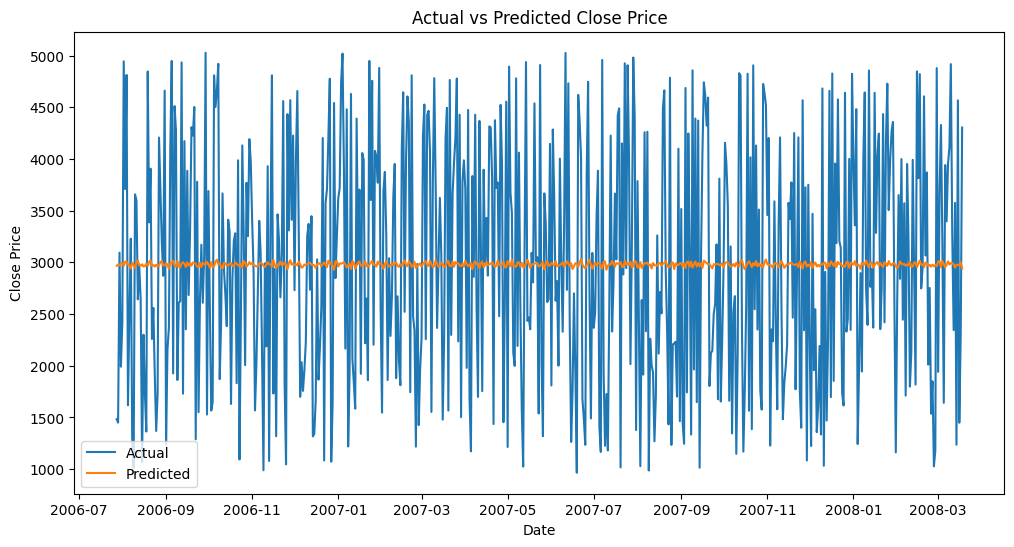

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test["Date"], y_test, label="Actual")
plt.plot(test["Date"], preds, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

## Plot Interpretation

The plot compares the actual closing prices with the predicted closing prices from the baseline model.

- The actual line moves up and down a lot.  
  This shows that the market is very volatile and changes quickly.

- The predicted line is almost flat.  
  This happens because the model is very simple and only uses the last few days of closing prices.  
  It cannot react to sudden jumps or drops in the market.

This difference between the two lines is expected.  
It shows that the baseline model is too simple to capture real market behaviour, which is exactly the point of Q1.  
The plot helps demonstrate why more advanced models will be needed in later questions.


## Conclusion
The baseline model I built uses only the last few closing prices (lag_1, lag_2, lag_3) to predict the next closing price. This is a very simple approach, and the results show exactly what we would expect from such a basic model.

The actual closing prices move up and down a lot; the market is noisy and changes quickly. The predicted line, however, is almost flat. This happens because the model can only learn very simple patterns, like “tomorrow will be similar to yesterday.” It cannot react to big jumps, drops, or sudden changes in the market.

The error values (MAE and RMSE) confirm that the model is not very accurate. This is normal for a baseline model. The purpose here is not to get perfect predictions, but to show that simple lag features are not enough to capture how financial markets behave.

Overall, this baseline model helps me understand that the dataset does not have strong short‑term predictability using only past closing prices. More advanced models will be needed in later questions to capture more complex behaviour.